<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
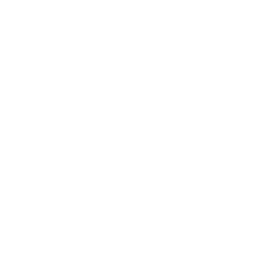
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Agrupamiento de Eficiencia Energética de Edificios</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energía / Análisis de Sostenibilidad &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este ejemplo práctico agrupa una cartera de edificios comerciales según cinco métricas de eficiencia energética — Intensidad de Uso Energético (EUI), razón de eficiencia HVAC, resistencia térmica de la envolvente, densidad de potencia de iluminación y porcentaje de compensación renovable — para identificar categorías de desempeño diferenciadas orientadas a programas de incentivos de las empresas de servicios públicos. El análisis usa **PROC FASTCLUS** con `REPLACE=FULL` (reemplazo completo de semillas) y compara las soluciones k=3, 4, 5 y 6 según el R-cuadrado global, el estadístico pseudo-F y el tamaño mínimo de grupo. La solución k=4 se perfila luego en detalle y cada grupo se asigna a una categoría de eficiencia accionable. Como este entorno se ejecuta sin licencia, la demostración se limita a una muestra de 100 edificios; el mismo programa escala sin cambios a una cartera completa.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Métricas anuales de eficiencia energética por edificio (sintéticas) | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generar métricas sintéticas de energía de edificios
   Indicadores de eficiencia de edificios comerciales
   -------------------------------------------------------- */
DATOS work.building_metrics;
    LLAMAR streaminit(42);
    ARREGLO btypes[5] $15 _temporary_ ('OFICINA' 'MINORISTA' 'ALMACEN' 'HOSPITAL' 'ESCUELA');
    ARREGLO regions[4] $12 _temporary_ ('NORESTE' 'SURESTE' 'MEDIOOESTE' 'OESTE');
    HACER building_id = 1 HASTA 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        building_type = btypes[type_idx];
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Intensidad de Uso Energético (kBtu/pie²/año) */
        eui = round(rand('normal', 85, 35), 0.1);
        SI eui < 15 ENTONCES eui = 15;
        SI eui > 250 ENTONCES eui = 250;

        /* Razón de eficiencia HVAC (equivalente a COP) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        SI hvac_efficiency < 1.0 ENTONCES hvac_efficiency = 1.0;
        SI hvac_efficiency > 6.0 ENTONCES hvac_efficiency = 6.0;

        /* Resistencia térmica de la envolvente (valor R) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        SI envelope_r_value < 5 ENTONCES envelope_r_value = 5;
        SI envelope_r_value > 40 ENTONCES envelope_r_value = 40;

        /* Densidad de potencia de iluminación (W/pie²) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        SI lighting_wpf < 0.3 ENTONCES lighting_wpf = 0.3;
        SI lighting_wpf > 2.5 ENTONCES lighting_wpf = 2.5;

        /* Porcentaje de compensación con energía renovable */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        SI renewable_pct > 80 ENTONCES renewable_pct = 80;

        /* Antigüedad del edificio en años */
        building_age = int(rand('uniform') * 80) + 1;

        /* Área de piso (miles de pies cuadrados) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        SI floor_area_ksf > 500 ENTONCES floor_area_ksf = 500;

        SALIDA;
    END;
    ELIMINAR type_idx reg_idx;
EJECUTAR;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.65 seconds
  cpu   1.65 seconds


---

In [2]:
/* --------------------------------------------------------
   Distribuciones básicas de métricas energéticas por tipo de edificio
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.building_metrics n mean std;
    CLASE building_type;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETIQUETA building_type = 'Tipo de Edificio'
          eui = 'Intensidad de Uso Energético (EUI)'
          hvac_efficiency = 'Eficiencia HVAC (COP)'
          envelope_r_value = 'Resistencia Térmica de la Envolvente (R)'
          lighting_wpf = 'Densidad de Potencia de Iluminación (W/pie²)'
          renewable_pct = 'Compensación Renovable (%)';
    TÍTULO 'Métricas Energéticas por Tipo de Edificio';
EJECUTAR;

                                       Métricas Energéticas por Tipo de Edificio                                        

                                                  The MEANS Procedure

                              Analysis Variable : eui Intensidad de Uso Energético (EUI)

        Tipo de Edificio          N Obs           Mean        Std Dev
        -------------------------------------------------------------
        ALMACEN                      20     90.8900000     33.5993249
        ESCUELA                      19     89.7000000     39.0498542
        HOSPITAL                     25     87.9040000     35.2632892
        MINORISTA                    16     79.7312500     42.6818106
        OFICINA                      20     73.0550000     40.3950163
        -------------------------------------------------------------

                               Analysis Variable : hvac_efficiency Eficiencia HVAC (COP)

        Tipo de Edificio          N Obs           Mean        Std 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                       Métricas Energéticas por Tipo de Edificio                                        




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


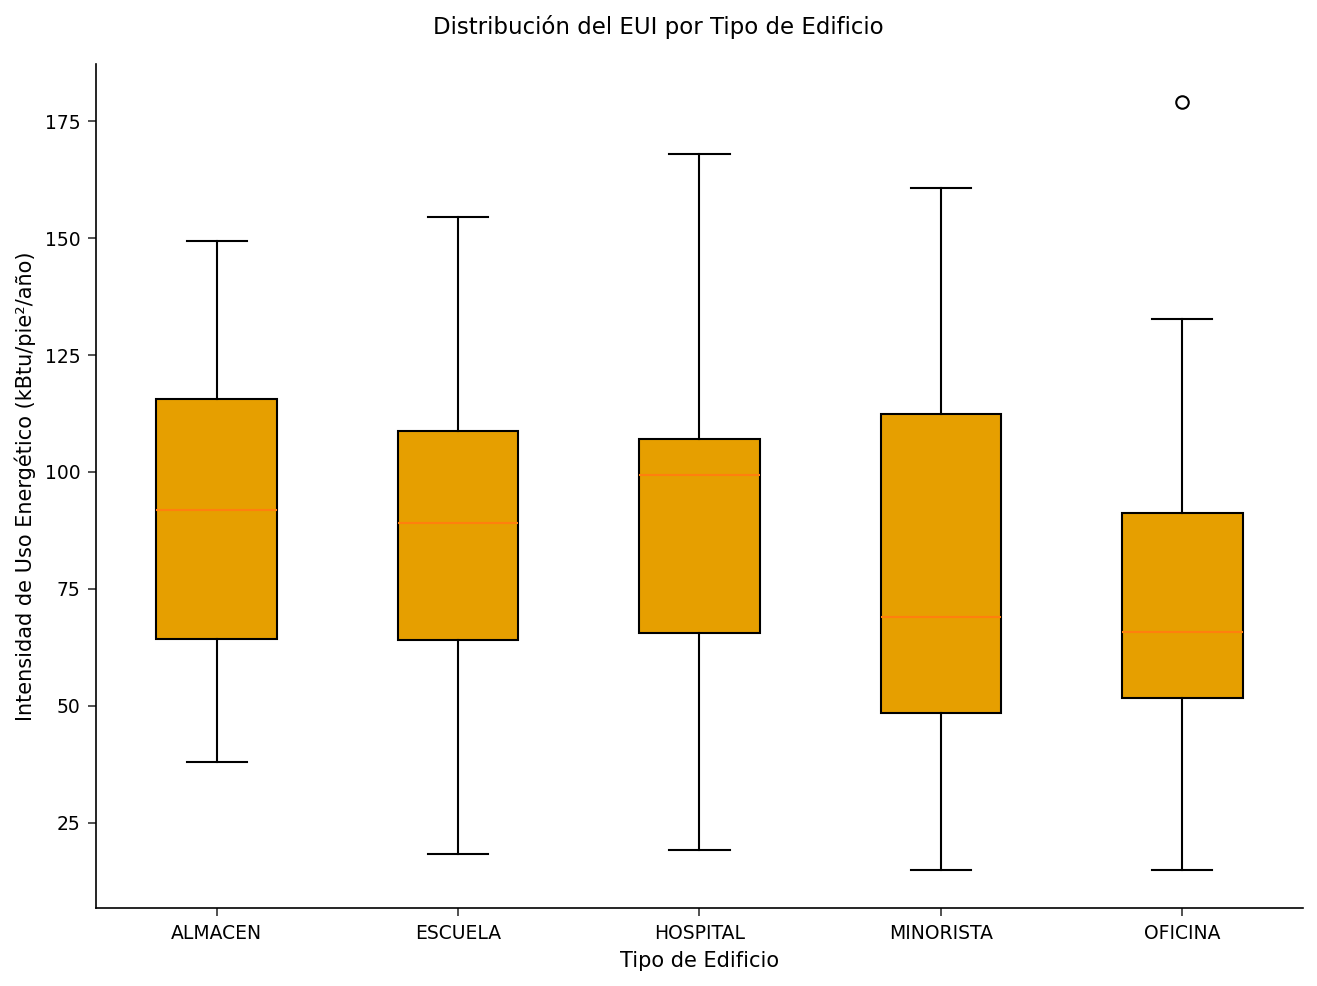

In [3]:
/* --------------------------------------------------------
   Distribución del EUI por tipo de edificio
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS ETIQUETA='Tipo de Edificio';
    YAXIS ETIQUETA='Intensidad de Uso Energético (kBtu/pie²/año)';
    TÍTULO 'Distribución del EUI por Tipo de Edificio';
EJECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Estandarizar las métricas de eficiencia
   -------------------------------------------------------- */
PROCEDIMIENTO STANDARD DATOS=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
EJECUTAR;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   Agrupamiento k-means: k=3 con REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMIENTO FASTCLUS DATOS=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETIQUETA eui = 'Intensidad de Uso Energético (EUI)'
          hvac_efficiency = 'Eficiencia HVAC (COP)'
          envelope_r_value = 'Resistencia Térmica de la Envolvente (R)'
          lighting_wpf = 'Densidad de Potencia de Iluminación (W/pie²)'
          renewable_pct = 'Compensación Renovable (%)';
    TÍTULO 'Agrupamiento de Eficiencia de Edificios: k=3 REPLACE=FULL';
EJECUTAR;

                                       Métricas Energéticas por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   Agrupamiento k-means: k=4 con REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMIENTO FASTCLUS DATOS=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETIQUETA eui = 'Intensidad de Uso Energético (EUI)'
          hvac_efficiency = 'Eficiencia HVAC (COP)'
          envelope_r_value = 'Resistencia Térmica de la Envolvente (R)'
          lighting_wpf = 'Densidad de Potencia de Iluminación (W/pie²)'
          renewable_pct = 'Compensación Renovable (%)';
    TÍTULO 'Agrupamiento de Eficiencia de Edificios: k=4 REPLACE=FULL';
EJECUTAR;

                                       Métricas Energéticas por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   Agrupamiento k-means: k=5 con REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMIENTO FASTCLUS DATOS=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETIQUETA eui = 'Intensidad de Uso Energético (EUI)'
          hvac_efficiency = 'Eficiencia HVAC (COP)'
          envelope_r_value = 'Resistencia Térmica de la Envolvente (R)'
          lighting_wpf = 'Densidad de Potencia de Iluminación (W/pie²)'
          renewable_pct = 'Compensación Renovable (%)';
    TÍTULO 'Agrupamiento de Eficiencia de Edificios: k=5 REPLACE=FULL';
EJECUTAR;

                                       Métricas Energéticas por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   Agrupamiento k-means: k=6 con REPLACE=FULL
   -------------------------------------------------------- */
PROCEDIMIENTO FASTCLUS DATOS=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETIQUETA eui = 'Intensidad de Uso Energético (EUI)'
          hvac_efficiency = 'Eficiencia HVAC (COP)'
          envelope_r_value = 'Resistencia Térmica de la Envolvente (R)'
          lighting_wpf = 'Densidad de Potencia de Iluminación (W/pie²)'
          renewable_pct = 'Compensación Renovable (%)';
    TÍTULO 'Agrupamiento de Eficiencia de Edificios: k=6 REPLACE=FULL';
EJECUTAR;

                                       Métricas Energéticas por Tipo de Edificio                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Comparar la calidad del agrupamiento entre k=3-6
   Calcular el R-cuadrado dentro de grupos y el tamaño mínimo de grupo
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROCEDIMIENTO FRECUENCIAS DATOS=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (RENOMBRAR=(count=n_buildings));
EJECUTAR;

PROCEDIMIENTO SQL NOPRINT;
    SELECCIONAR MIN(n_buildings) INTO :min_size_k&k
    DESDE work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                       Métricas Energéticas por Tipo de Edificio                                        

                                       Métricas Energéticas por Tipo de Edificio                                        

                                       Métricas Energéticas por Tipo de Edificio                                        

                                       Métricas Energéticas por Tipo de Edificio                                        




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                 Perfiles de Categoría de Eficiencia de Edificios (k=4)                                 

                                                  The MEANS Procedure

                                     Analysis Variable : eui Intensidad de Uso Energético (EUI)

                                                N
                                     Grupo    Obs             Mean         Std Dev
                                     ---------------------------------------------
                                     1         23       63.7782609      31.5423086
                                     2         17      122.5941176      36.0679995
                                     3         26       94.0076923      30.8825378
                                     4         34       72.3911765      31.7411154
                                     ---------------------------------------------

                                       Analysis Variable : hvac_efficiency Efi


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


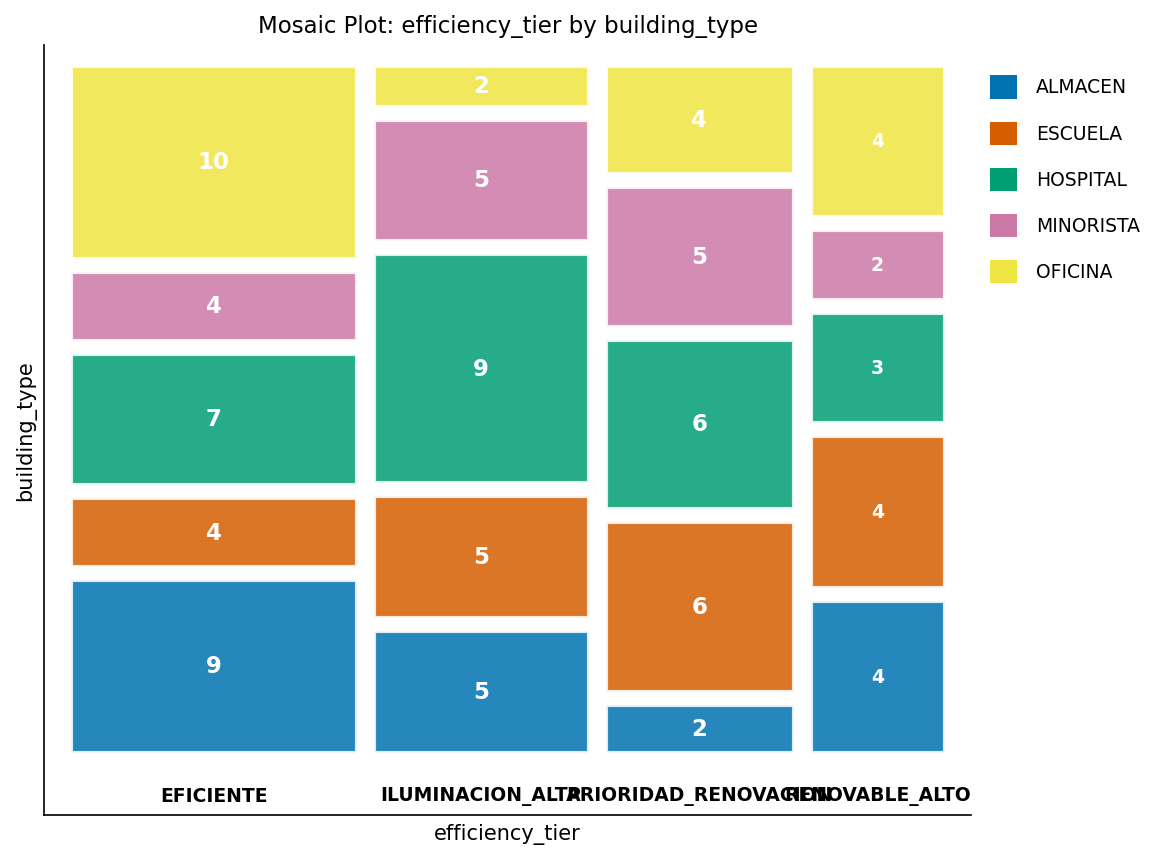

In [10]:
/* --------------------------------------------------------
   Perfilar la solución seleccionada k=4
   -------------------------------------------------------- */
DATOS work.bldg_profiled;
    COMBINAR work.building_metrics
          work.bldg_clust4 (MANTENER=building_id CLUSTER distance);
    POR building_id;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.bldg_profiled mean std;
    CLASE CLUSTER;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    ETIQUETA cluster = 'Grupo'
          eui = 'Intensidad de Uso Energético (EUI)'
          hvac_efficiency = 'Eficiencia HVAC (COP)'
          envelope_r_value = 'Resistencia Térmica de la Envolvente (R)'
          lighting_wpf = 'Densidad de Potencia de Iluminación (W/pie²)'
          renewable_pct = 'Compensación Renovable (%)'
          building_age = 'Antigüedad del Edificio (años)';
    TÍTULO 'Perfiles de Categoría de Eficiencia de Edificios (k=4)';
EJECUTAR;

/* Etiquetar las categorías de eficiencia a partir de los centroides
   observados en k=4:
   Grupo 4 = mejor HVAC (3.89) con EUI bajo  -> EFICIENTE
   Grupo 2 = mayor compensación renovable (28%) pero mayor EUI -> RENOVABLE_ALTO
   Grupo 3 = mayor carga de iluminación, HVAC débil, EUI medio -> ILUMINACION_ALTA
   Grupo 1 = EUI bajo pero HVAC más débil + envolvente más delgada -> PRIORIDAD_RENOVACION */
DATOS work.bldg_tiered;
    ESTABLECER work.bldg_profiled;
    LONGITUD efficiency_tier $24;
    SI CLUSTER = 4 ENTONCES efficiency_tier = 'EFICIENTE';
    SINO SI CLUSTER = 2 ENTONCES efficiency_tier = 'RENOVABLE_ALTO';
    SINO SI CLUSTER = 3 ENTONCES efficiency_tier = 'ILUMINACION_ALTA';
    SINO SI CLUSTER = 1 ENTONCES efficiency_tier = 'PRIORIDAD_RENOVACION';
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    ETIQUETA efficiency_tier = 'Categoría de Eficiencia'
          building_type = 'Tipo de Edificio';
    TÍTULO 'Categoría de Eficiencia por Tipo de Edificio';
EJECUTAR;

---

### Interpretación

Con `REPLACE=FULL`, cada valor de k convergió limpiamente. En las cuatro soluciones, el R-cuadrado global aumentó de forma monótona con k — 0.305 (k=3), 0.410 (k=4), 0.459 (k=5), 0.515 (k=6) — mientras que el estadístico pseudo-F alcanzó su máximo en **k=4 (22.23)** antes de disminuir (20.13 en k=5, 19.93 en k=6). Combinado con un tamaño mínimo de grupo de 17 edificios en k=4 (frente a 13 en k=5 y 10 en k=6), la **solución k=4** ofrece el mejor equilibrio entre separación y estabilidad de categorías, por lo que se perfila a continuación.

Los cuatro grupos de k=4 corresponden a perfiles de eficiencia claramente distintos (medias del perfil de PROC MEANS anterior):

- **Eficiente (Grupo 4, n=34):** el grupo mejor equipado — mayor eficiencia HVAC (COP 3.89) con un EUI bajo-moderado de 72.4 kBtu/pie²/año, con envolvente adecuada (R 18.8) y compensación renovable modesta (11.0%).
- **Renovable alto (Grupo 2, n=17):** los mayores consumidores absolutos (EUI 122.6) pero también, por mucho, la mayor compensación renovable (28.2%), con HVAC de rango medio (COP 3.42). Alto consumo combinado con generación en sitio.
- **Iluminación alta (Grupo 3, n=26):** EUI medio (94.0) impulsado por la mayor densidad de potencia de iluminación (1.35 W/pie²) y el segundo HVAC más débil (COP 2.42), a pesar de la envolvente más gruesa (R 19.6).
- **Prioridad de renovación (Grupo 1, n=23):** EUI bajo en apariencia (63.8) pero el HVAC más débil (COP 2.28) y la envolvente más delgada (R 12.5) — edificios pequeños o poco usados pero mal equipados, los candidatos más claros para renovaciones de envolvente y HVAC.

La tabulación cruzada de categoría por tipo de edificio muestra que las oficinas (10) y los almacenes (9) dominan la categoría eficiente, mientras que los hospitales se concentran en la categoría de iluminación alta (9 de 26). La categoría de prioridad de renovación se distribuye entre tipos, liderada por hospitales y escuelas (6 cada uno de 23). Para el diseño de programas, los 23 edificios de prioridad de renovación y los 26 de iluminación alta son los objetivos naturales para incentivos de HVAC e iluminación respectivamente, mientras que los 17 edificios de renovable alto — que ya generan energía en sitio — se adaptan mejor a la reducción de demanda que a incentivos adicionales de generación.

---

In [11]:
/* --------------------------------------------------------
   Exportar las categorías de eficiencia de edificios y los
   perfiles de centroides
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>